In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [12]:
# ── 1. LOAD DATA ─────────────────────────────────────────────
df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)       # (7043, 21)
print(df.head())
print(df.info())


(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [13]:
key_cols = ['gender', 'SeniorCitizen', 'tenure', 'Contract', 'MonthlyCharges', 'Churn']

styled = (df[key_cols].head(5)
    .style
    .set_caption("Sample Customer Data (5 rows)")
    .highlight_null(color='lightcoral')           # highlight any NaN in red
    .applymap(lambda v: 'color: red; font-weight: bold'
              if v == 'Yes' else '', subset=['Churn'])  # highlight churners
    .format({'MonthlyCharges': '${:.2f}'})        # format money nicely
)

styled


AttributeError: 'Styler' object has no attribute 'applymap'

In [ ]:
# ── 2. BASIC STATS ───────────────────────────────────────────
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [ ]:
# Check how many blank strings exist in TotalCharges
blank_count = (df['TotalCharges'].str.strip() == '').sum()
print(f"Blank strings in TotalCharges: {blank_count}")


Blank strings in TotalCharges: 11


In [ ]:
# Churn rate
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
# ── 3. FIX MISSING VALUES ────────────────────────────────────
# TotalCharges has blank strings — convert to numeric first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
# Fill missing TotalCharges with the column mean
avg_total = df['TotalCharges'].mean()
df['TotalCharges'].fillna(avg_total, inplace=True)

print(df.isnull().sum())  # confirm no more nulls

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


C:\Users\Arij\AppData\Local\Temp\ipykernel_23216\1961870752.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(avg_total, inplace=True)


In [ ]:
# ── 4. ENCODE CATEGORICAL → NUMERIC ──────────────────────────
# Convert Churn to binary: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
# Drop CustomerID (not useful for ML)
df.drop('customerID', axis=1, inplace=True)

In [ ]:
# One-hot encode all remaining categorical columns
df_encoded = pd.get_dummies(df)
print(df_encoded.shape)

(7043, 46)


In [ ]:
# ── 5. TRAIN / VALIDATION / TEST SPLIT ───────────────────────
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


In [ ]:
# Step 1: split off 10% test set
X_remaining, X_test, y_remaining, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

In [ ]:
# Step 2: split remaining into 80% train, 10% val
X_train, X_val, y_train, y_val = train_test_split(
    X_remaining, y_remaining, test_size=0.111, random_state=42  # 0.111 ≈ 10/90
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 5634, Val: 704, Test: 705


Text(0, 0.5, '')

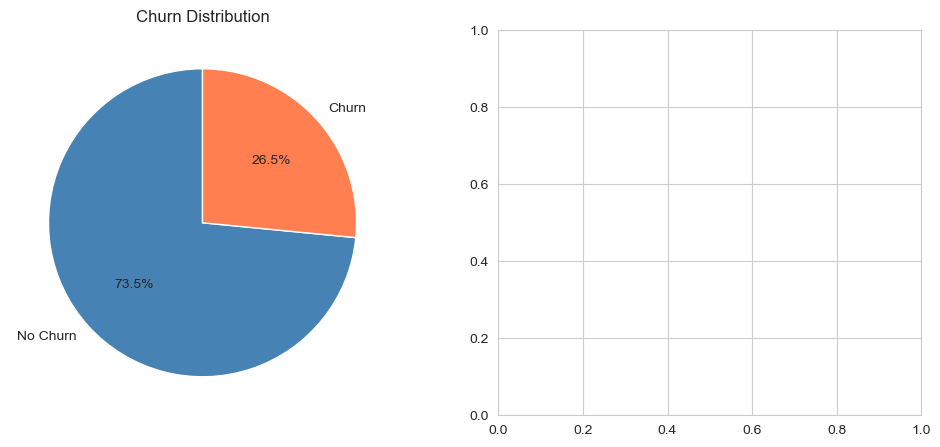

In [ ]:

# ── 6. VISUALIZATIONS ────────────────────────────────────────
sns.set_style('whitegrid')

# --- 6a. Churn Distribution (Pie Chart) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Churn'].value_counts().plot(
    kind='pie', ax=axes[0],
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=['steelblue', 'coral'],
    startangle=90
)
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('')

C:\Users\Arij\AppData\Local\Temp\ipykernel_23216\2477201960.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot1=sns.barplot(


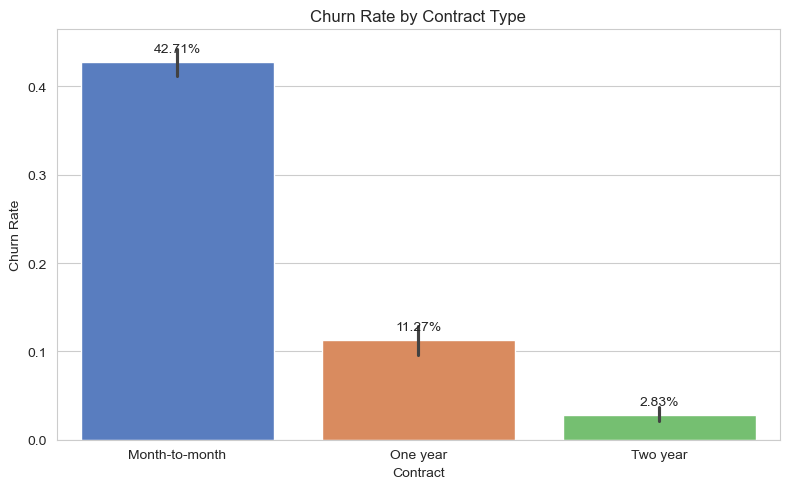

In [ ]:
# --- 6b. Churn by Contract Type (Bar Chart) ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

bar_plot1=sns.barplot(
    x='Contract',
    y='Churn',
    data=df,
    palette='muted'
)

for bar in bar_plot1.patches:
    height = bar.get_height()
    bar_plot1.annotate(f'{height:.2%}',  # format as percentage
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 5),  # offset text above bar
                       textcoords='offset points',
                       ha='center', va='bottom',
                       fontsize=10
                       )
     
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.show()


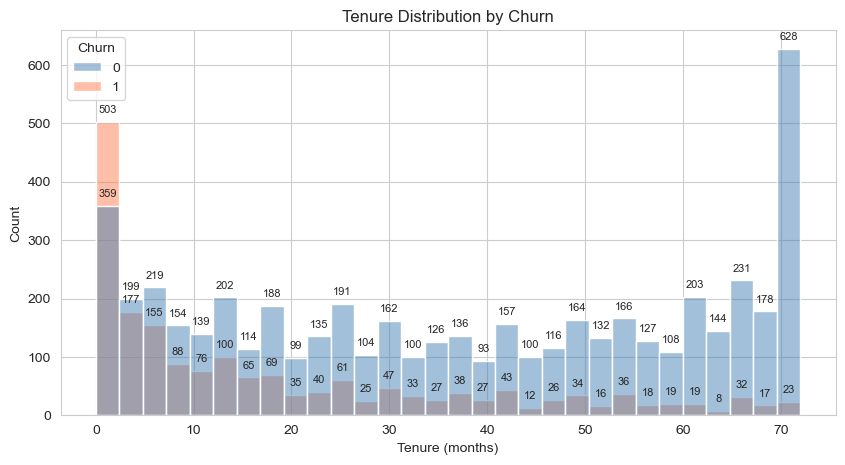

In [ ]:
# --- 6c. Tenure Distribution by Churn ---
plt.figure(figsize=(10, 5))
hist_plot1=sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette=['steelblue', 'coral'])
for bar in hist_plot1.patches:
    height = bar.get_height()
    hist_plot1.annotate(f'{height:.0f}',  # show count
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 5),  # offset text above bar
                       textcoords='offset points',
                       ha='center', va='bottom',
                       fontsize=8
                       )
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.savefig('tenure_churn.png')
plt.show()

C:\Users\Arij\AppData\Local\Temp\ipykernel_23216\2698042166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


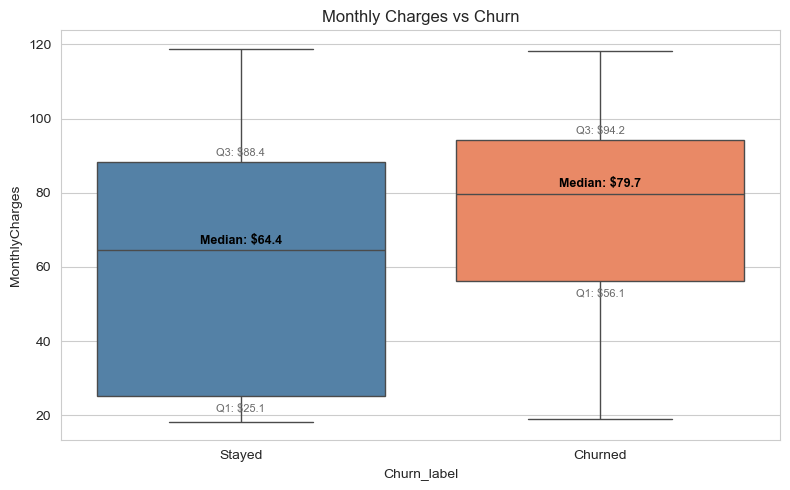

In [ ]:
plt.figure(figsize=(8, 5))

df['Churn_label'] = df['Churn'].map({1: 'Churned', 0: 'Stayed'})

ax = sns.boxplot(
    x='Churn_label', y='MonthlyCharges', data=df,
    palette=['steelblue', 'coral']
)

# Calculate stats per group in the SAME order as the plot
groups = ['Stayed', 'Churned']

for i, group in enumerate(groups):
    group_data = df[df['Churn_label'] == group]['MonthlyCharges']
    
    median = group_data.median()
    q1     = group_data.quantile(0.25)
    q3     = group_data.quantile(0.75)

    # Annotate median (inside box, middle line)
    ax.text(i, median + 1, f'Median: ${median:.1f}',
            ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

    # Annotate Q1 (bottom of box)
    ax.text(i, q1 - 2, f'Q1: ${q1:.1f}',
            ha='center', va='top', fontsize=8, color='dimgray')

    # Annotate Q3 (top of box)
    ax.text(i, q3 + 1, f'Q3: ${q3:.1f}',
            ha='center', va='bottom', fontsize=8, color='dimgray')

plt.title('Monthly Charges vs Churn')
plt.tight_layout()
plt.savefig('monthly_charges_churn.png')
plt.show()


In [ ]:
# --- 6e. Correlation Heatmap (top features) ---
plt.figure(figsize=(12, 8))
corr = df_encoded.corr()[['Churn']].sort_values('Churn', ascending=False).head(15)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Top Features Correlated with Churn')
plt.savefig('correlation_heatmap.png')
plt.show()

NameError: name 'plt' is not defined

In [ ]:
print("✅ EDA complete! Charts saved as PNG files.")

✅ EDA complete! Charts saved as PNG files.
